# Capítulo 1 — Fundamentos da Atmosfera: laboratório numérico

**Curso de Meteorologia Prática** — baseado em R. Stull, *Practical Meteorology* (CC BY-NC-SA 4.0).

| Caso | O que fazemos | Ferramenta |
|---|---|---|
| 1 | atmosfera padrão ICAO: perfis anotados de $T$, $P$, $\rho$ | `ambiance` |
| 2 | **integração numérica** da EDO hidrostática $dP/dz=-\rho g$ | `scipy.solve_ivp` |
| 3 | equação hipsométrica: altimetria e espessura 1000–500 hPa | NumPy |
| 4 | sondagem real × atmosfera padrão (diagrama Skew-T) | `MetPy` |
| 5 | temperatura virtual: umidade e densidade do ar | `MetPy` |

No fim há **exercícios numéricos** (N1–N4) para você resolver — as soluções estão em `cap01_solucoes.ipynb`, junto com os exercícios teóricos T1–T5 das notas de aula.

Ambiente: `conda activate meteo` (ver `environment.yml`).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys; sys.path.append('../comum')
from estilo_meteo import aplicar_estilo, CORES, sombrear_camadas, marco
aplicar_estilo()

# constantes do Cap. 1 (Stull)
Rd = 287.0        # J kg-1 K-1 — constante do ar seco
g  = 9.8          # m s-2
a  = Rd / g       # ≈ 29,3 m/K — constante hipsométrica
P0 = 101.325      # kPa — pressão padrão ao nível do mar
print(f'a = Rd/g = {a:.1f} m/K  (livro: 29,3 m/K)')

a = Rd/g = 29.3 m/K  (livro: 29,3 m/K)


## Caso 1 — A atmosfera padrão ICAO, anotada

O pacote [`ambiance`](https://pypi.org/project/ambiance/) implementa a atmosfera padrão ICAO 1993 — exatamente a tabela da aula. Vamos *ver* a atmosfera: perfis de $T$, $P$ e $\rho$ com as camadas sombreadas e alguns marcos de altitude para dar escala humana.

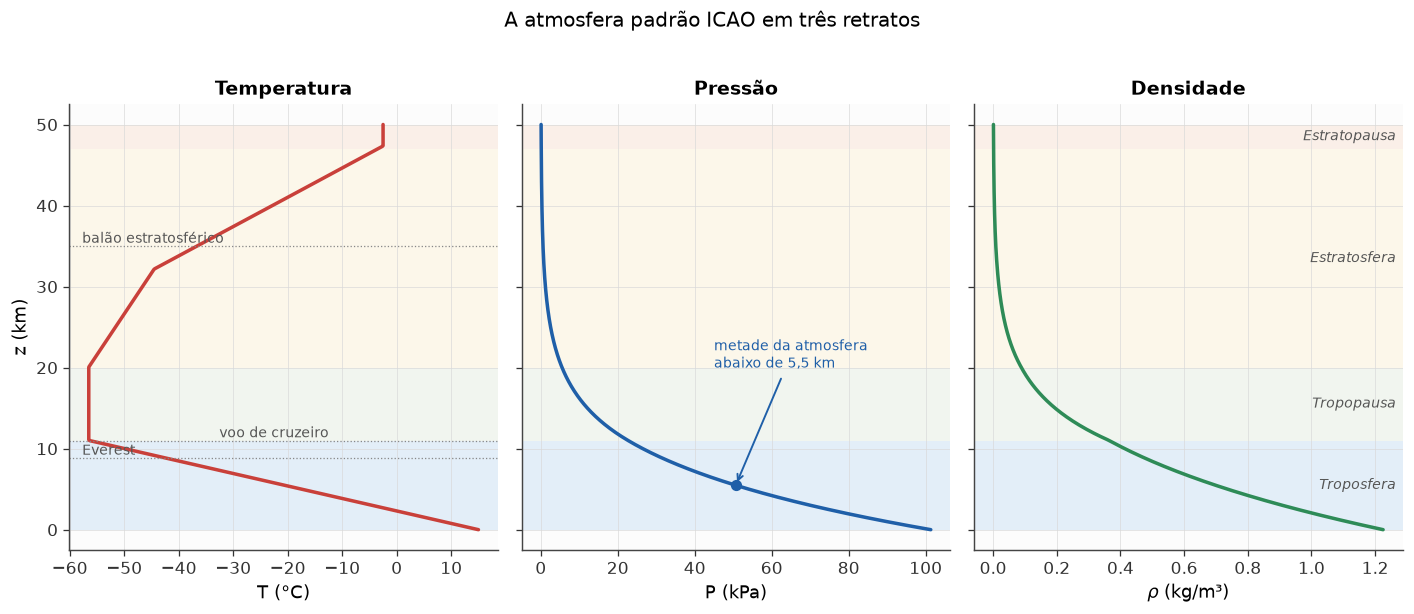

In [2]:
from ambiance import Atmosphere

z = np.linspace(0, 50e3, 501)
atm = Atmosphere(z)

fig, axs = plt.subplots(1, 3, figsize=(12.5, 5.2), sharey=True)
fig.suptitle('A atmosfera padrão ICAO em três retratos', y=1.02)

for ax in axs:
    sombrear_camadas(ax, zmax_km=50, rotulos=(ax is axs[2]))

axs[0].plot(atm.temperature - 273.15, z/1e3, color=CORES['vermelho'])
axs[0].set(xlabel='T (°C)', ylabel='z (km)', title='Temperatura')
marco(axs[0], 8.85, 'Everest')
marco(axs[0], 11, 'voo de cruzeiro', x_frac=0.35)
marco(axs[0], 35, 'balão estratosférico')

axs[1].plot(atm.pressure/1e3, z/1e3, color=CORES['azul'])
axs[1].set(xlabel='P (kPa)', title='Pressão')
z_meia = z[np.argmin(np.abs(atm.pressure - atm.pressure[0]/2))]/1e3
axs[1].annotate('metade da atmosfera\nabaixo de '
                + f'{z_meia:.1f} km'.replace('.', ','),
                xy=(P0/2, z_meia), xytext=(45, 20),
                fontsize=9, color=CORES['azul'],
                arrowprops=dict(arrowstyle='->', color=CORES['azul'], lw=1.2))
axs[1].scatter([P0/2], [z_meia], color=CORES['azul'], zorder=5)

axs[2].plot(atm.density, z/1e3, color=CORES['verde'])
axs[2].set(xlabel='$\\rho$ (kg/m³)', title='Densidade')

fig.tight_layout(); plt.show()

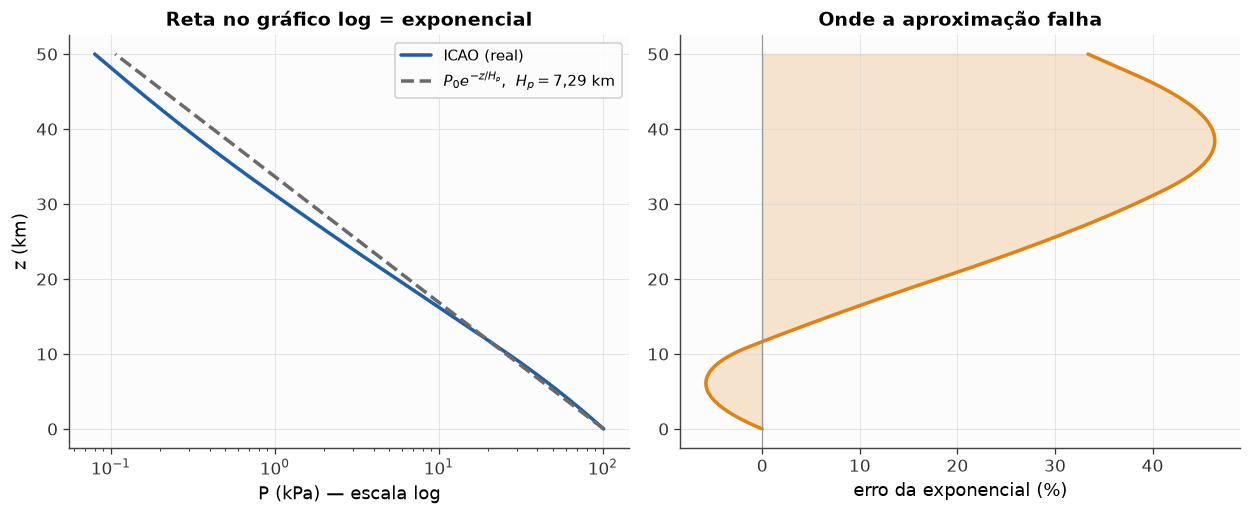

Erro máximo da exponencial até 20 km: 17.9 %
H_rho ajustado (0–20 km) = 7.57 km (livro: 8,55 km)


In [3]:
# Teste da exponencial do livro: em escala log-linear, exponencial vira reta
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.6))

Hp = 7.29e3
ax1.semilogx(atm.pressure/1e3, z/1e3, color=CORES['azul'], label='ICAO (real)')
ax1.semilogx(P0*np.exp(-z/Hp), z/1e3, '--', color=CORES['cinza'],
             label='$P_0e^{-z/H_p}$,  $H_p=7{,}29$ km')
ax1.set(xlabel='P (kPa) — escala log', ylabel='z (km)',
        title='Reta no gráfico log = exponencial')
ax1.legend()

erro = 100*(P0*np.exp(-z/Hp) - atm.pressure/1e3)/(atm.pressure/1e3)
ax2.plot(erro, z/1e3, color=CORES['laranja'])
ax2.axvline(0, color='#999999', lw=0.8)
ax2.fill_betweenx(z/1e3, erro, 0, color=CORES['laranja'], alpha=0.2)
ax2.set(xlabel='erro da exponencial (%)', title='Onde a aproximação falha')
fig.tight_layout(); plt.show()

mask = z <= 20e3
Hrho = -1/np.polyfit(z[mask], np.log(atm.density[mask]), 1)[0]
print(f'Erro máximo da exponencial até 20 km: {np.max(np.abs(erro[mask])):.1f} %')
print(f'H_rho ajustado (0–20 km) = {Hrho/1e3:.2f} km (livro: 8,55 km)')

**Discussão em aula.** A exponencial com $H_p$ fixo erra menos de ~5 % em quase toda a troposfera — excelente para estimativas de cabeça. E $H_p \ne H_\rho$ porque $T$ varia com $z$ (exercício T1).

## Caso 2 — Resolvendo a EDO hidrostática numericamente

A tabela ICAO não é mágica: ela é a **solução da EDO**

$$\frac{dP}{dz} = -\rho g = -\frac{g}{\Re_d\,T(z)}\,P$$

com o perfil $T(z)$ por trechos lineares da atmosfera padrão. Vamos integrá-la com `scipy.integrate.solve_ivp` e comparar com o `ambiance` e com a exponencial isotérmica. É o primeiro contato do curso com **previsão numérica em miniatura**: uma lei física + condição inicial + integrador = perfil completo.

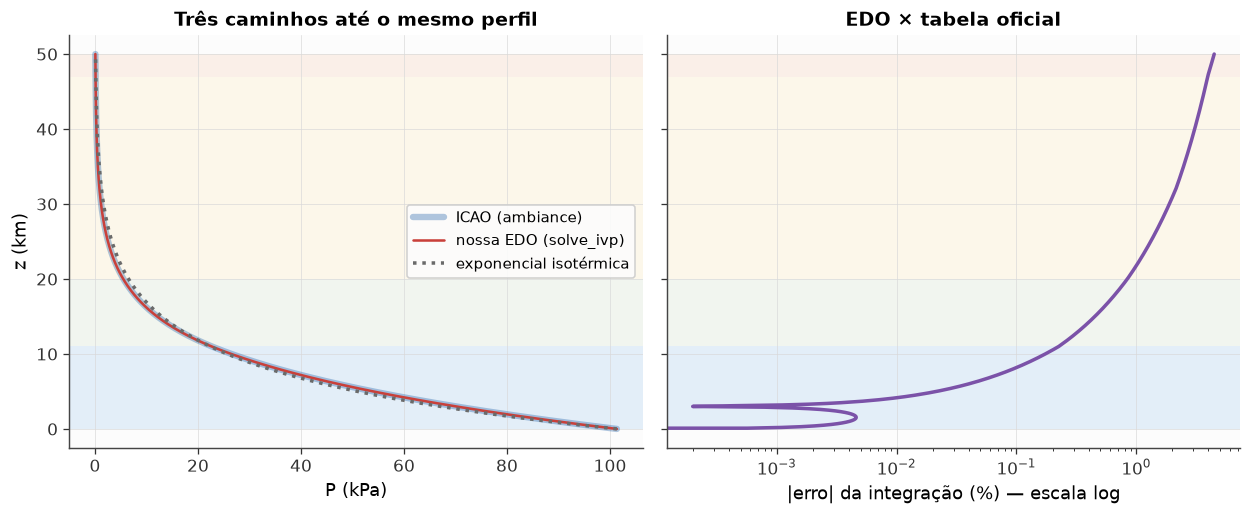

Erro máximo da integração numérica (0–50 km): 4.467 %


In [4]:
from scipy.integrate import solve_ivp

def T_icao(z_m):
    """Temperatura (K) da atmosfera padrão ICAO até 51 km, por trechos lineares."""
    z_km = z_m/1e3
    zs   = np.array([0, 11, 20, 32, 47, 51])          # nós (km)
    Ts   = np.array([288.15, 216.65, 216.65, 228.65, 270.65, 270.65])
    return np.interp(z_km, zs, Ts)

def dPdz(z_m, P):
    return -g * P / (Rd * T_icao(z_m))

sol = solve_ivp(dPdz, [0, 50e3], [P0*1e3], dense_output=True,
                rtol=1e-8, atol=1e-6)
P_num = sol.sol(z)[0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.6), sharey=True)
sombrear_camadas(ax1, 50, rotulos=False); sombrear_camadas(ax2, 50, rotulos=False)
ax1.plot(atm.pressure/1e3, z/1e3, color=CORES['azul'], lw=4, alpha=0.35,
         label='ICAO (ambiance)')
ax1.plot(P_num/1e3, z/1e3, color=CORES['vermelho'], lw=1.6,
         label='nossa EDO (solve_ivp)')
ax1.plot(P0*np.exp(-z/Hp), z/1e3, ':', color=CORES['cinza'],
         label='exponencial isotérmica')
ax1.set(xlabel='P (kPa)', ylabel='z (km)', title='Três caminhos até o mesmo perfil')
ax1.legend()

ax2.semilogx(np.abs(P_num - atm.pressure)/atm.pressure*100, z/1e3,
             color=CORES['roxo'])
ax2.set(xlabel='|erro| da integração (%) — escala log',
        title='EDO × tabela oficial')
fig.tight_layout(); plt.show()

print(f'Erro máximo da integração numérica (0–50 km): '
      f'{np.max(np.abs(P_num-atm.pressure)/atm.pressure*100):.3f} %')

**Moral da história.** Com 10 linhas de física reproduzimos a tabela internacional com erro < 0,1 % — a diferença restante vem de detalhes ( $g$ variável com a altura, constantes ligeiramente diferentes). Guarde esta receita: *lei diferencial + condição inicial + integrador*. Os modelos de previsão do tempo (Cap. 20) fazem exatamente isso, só que com milhões de variáveis.

## Caso 3 — Equação hipsométrica: altimetria e espessura

$$z_2 - z_1 = a\,\bar T_v\,\ln\frac{P_1}{P_2},\qquad a = \frac{\Re_d}{g} = 29{,}3\ \mathrm{m/K}$$

Dois usos clássicos: **(a)** medir altura com um barômetro; **(b)** a *espessura* 1000–500 hPa como termômetro da baixa troposfera (regra operacional: 5400 m separa chuva de neve).

(a) queda de 0,4 kPa a 20 °C  →  subi 34 m


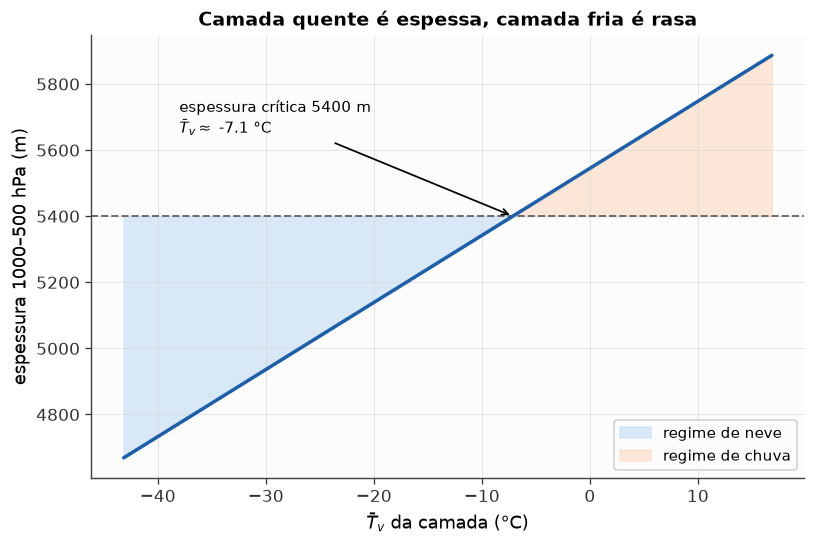

In [5]:
def espessura(P1, P2, Tv_medio):
    """Espessura hipsométrica (m) entre P1 e P2 (mesma unidade), Tv em K."""
    return a * Tv_medio * np.log(P1/P2)

# (a) altimetria: subo um prédio e o barômetro cai de 101,3 para 100,9 kPa
dz = espessura(101.3, 100.9, 293.0)
print(f'(a) queda de 0,4 kPa a 20 °C  →  subi {dz:.0f} m')

# (b) espessura 1000–500 hPa vs. temperatura média da camada
Tv_bar = np.linspace(230, 290, 200)
esp = espessura(1000.0, 500.0, Tv_bar)
Tv_5400 = 5400/(a*np.log(2))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(Tv_bar - 273.15, esp, color=CORES['azul'], zorder=4)
ax.axhline(5400, color=CORES['cinza'], ls='--', lw=1.2)
ax.fill_between(Tv_bar - 273.15, esp, 5400, where=esp<5400,
                color='#cfe3f5', alpha=0.8, label='regime de neve')
ax.fill_between(Tv_bar - 273.15, esp, 5400, where=esp>=5400,
                color='#fbe1d0', alpha=0.8, label='regime de chuva')
ax.annotate('espessura crítica 5400 m\n$\\bar{T}_v \\approx$ '
            f'{Tv_5400-273.15:.1f} °C',
            xy=(Tv_5400-273.15, 5400), xytext=(-38, 5650), fontsize=9.5,
            arrowprops=dict(arrowstyle='->', lw=1.1))
ax.set(xlabel='$\\bar{T}_v$ da camada (°C)',
       ylabel='espessura 1000–500 hPa (m)',
       title='Camada quente é espessa, camada fria é rasa')
ax.legend(loc='lower right')
plt.show()

**Exercício em sala.** Meça $P$ com o barômetro do seu celular no térreo e no último andar; use `espessura()` para estimar a altura do prédio e compare com o valor real. (Versão com dados prontos: exercício N3.)

## Caso 4 — Sondagem real × atmosfera padrão (`MetPy`)

Abaixo, uma sondagem tropical típica (níveis principais, estilo Campo de Marte/SBMT em verão). Em aula você pode substituir pelos dados do dia — o site da Univ. de Wyoming (`weather.uwyo.edu/upperair/sounding.html`) fornece a tabela; cole as colunas aqui ou use o pacote `siphon` para baixar automaticamente.

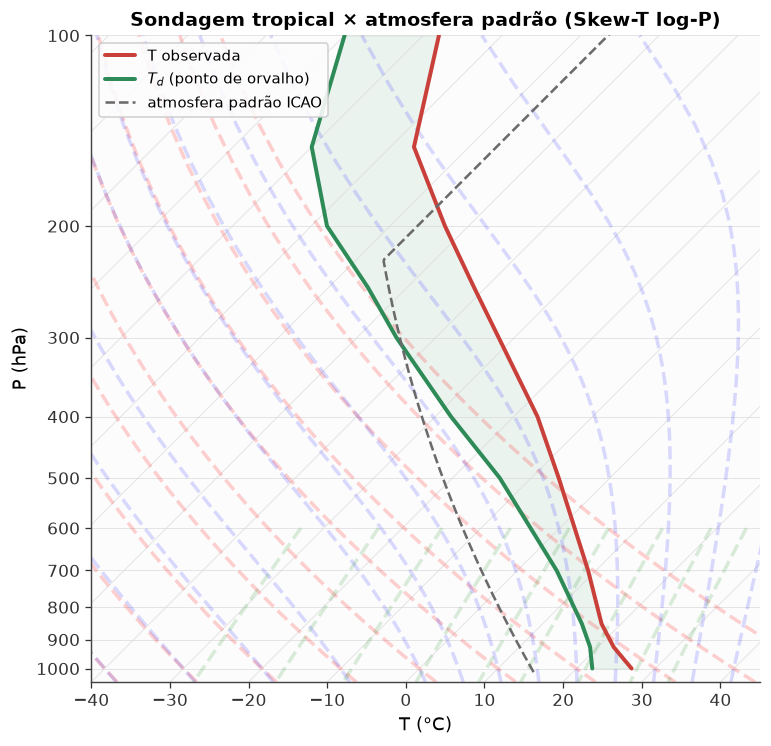

In [6]:
from metpy.units import units
import metpy.calc as mpcalc
from metpy.plots import SkewT

# sondagem tropical de exemplo: P (hPa), z (m), T (°C), Td (°C)
P_s  = np.array([1000, 925, 850, 700, 500, 400, 300, 250, 200, 150, 100]) * units.hPa
z_s  = np.array([80, 760, 1480, 3120, 5830, 7550, 9640, 10870, 12300, 14100, 16500]) * units.m
T_s  = np.array([27.0, 22.0, 17.5, 9.0, -6.5, -17.0, -32.0, -41.5, -53.0, -67.0, -78.0]) * units.degC
Td_s = np.array([22.0, 19.0, 15.0, 5.0, -14.0, -28.0, -45.0, -55.0, -68.0, -80.0, -90.0]) * units.degC

fig = plt.figure(figsize=(7.5, 7.5))
skew = SkewT(fig, rotation=45)
skew.plot(P_s, T_s, color=CORES['vermelho'], lw=2.5, label='T observada')
skew.plot(P_s, Td_s, color=CORES['verde'], lw=2.5, label='$T_d$ (ponto de orvalho)')
skew.shade_area(P_s, Td_s, T_s, color=CORES['verde'], alpha=0.08)

from ambiance import Atmosphere
z_grid = np.linspace(0, 17e3, 400)
atm_g = Atmosphere(z_grid)
skew.plot(atm_g.pressure/100*units.hPa, (atm_g.temperature-273.15)*units.degC,
          '--', color=CORES['cinza'], lw=1.6, label='atmosfera padrão ICAO')

skew.plot_dry_adiabats(alpha=0.18, color=CORES['laranja'])
skew.plot_moist_adiabats(alpha=0.14, color=CORES['verde'])
skew.plot_mixing_lines(alpha=0.14, color=CORES['azul'])
skew.ax.set_ylim(1050, 100); skew.ax.set_xlim(-40, 45)
skew.ax.set_xlabel('T (°C)'); skew.ax.set_ylabel('P (hPa)')
skew.ax.set_title('Sondagem tropical × atmosfera padrão (Skew-T log-P)')
skew.ax.legend(loc='upper left')
plt.show()

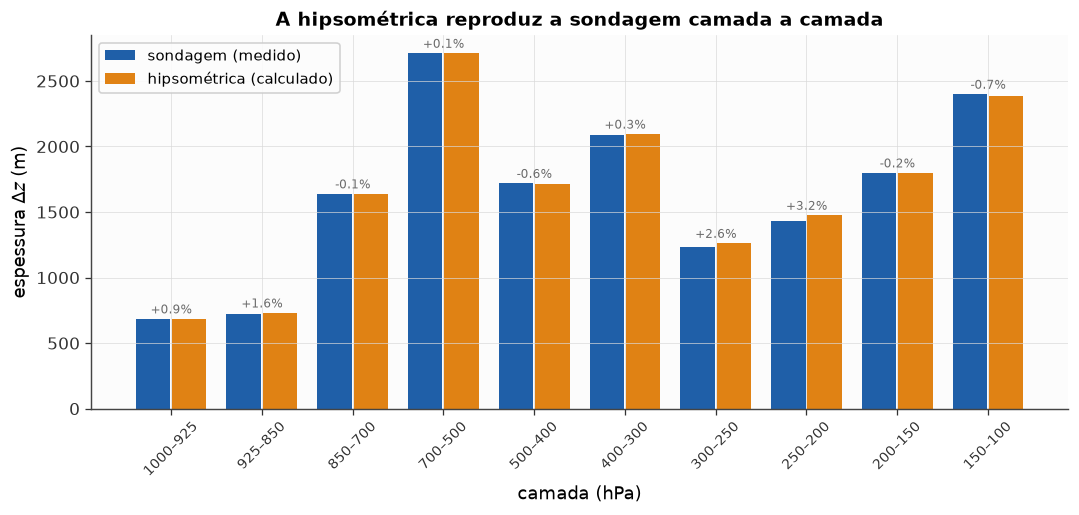

In [7]:
# Verificação quantitativa da hipsométrica contra as alturas reportadas na sondagem
r_s  = mpcalc.mixing_ratio_from_relative_humidity(
          P_s, T_s, mpcalc.relative_humidity_from_dewpoint(T_s, Td_s))
Tv_s = mpcalc.virtual_temperature(T_s, r_s).to('K')

rotulos, dz_obs_l, dz_hip_l = [], [], []
for i in range(len(P_s)-1):
    Tv_medio = 0.5*(Tv_s[i] + Tv_s[i+1])
    razao = (P_s[i]/P_s[i+1]).magnitude
    dz_hip_l.append(a * Tv_medio.magnitude * np.log(razao))
    dz_obs_l.append((z_s[i+1] - z_s[i]).magnitude)
    rotulos.append(f'{P_s[i].magnitude:.0f}–{P_s[i+1].magnitude:.0f}')

x = np.arange(len(rotulos))
fig, ax = plt.subplots(figsize=(9.5, 4.6))
ax.bar(x-0.2, dz_obs_l, 0.38, color=CORES['azul'], label='sondagem (medido)')
ax.bar(x+0.2, dz_hip_l, 0.38, color=CORES['laranja'], label='hipsométrica (calculado)')
ax.set_xticks(x); ax.set_xticklabels(rotulos, rotation=45, fontsize=8.5)
ax.set(xlabel='camada (hPa)', ylabel='espessura $\\Delta z$ (m)',
       title='A hipsométrica reproduz a sondagem camada a camada')
ax.legend()
for xi, (o, h) in enumerate(zip(dz_obs_l, dz_hip_l)):
    ax.text(xi, max(o, h)+40, f'{100*(h-o)/o:+.1f}%', ha='center', fontsize=7.5,
            color=CORES['cinza'])
fig.tight_layout(); plt.show()

**Discussão.** Erros de poucos por cento por camada — é assim que radiossondas convertem pressão em altura. Note no Skew-T como a troposfera tropical real é mais quente que a padrão em baixos níveis e como a tropopausa tropical (~16 km) é bem mais alta que os 11 km da atmosfera padrão.

## Caso 5 — Temperatura virtual: umidade e densidade do ar

$$T_v = T\,(1 + 0{,}61\,r)$$

O ar úmido é menos denso que o ar seco à mesma $(P,T)$; dinamicamente ele se comporta como ar seco à temperatura $T_v > T$. O efeito é pequeno em kelvins — e decisivo para convecção (Caps. 5 e 14).

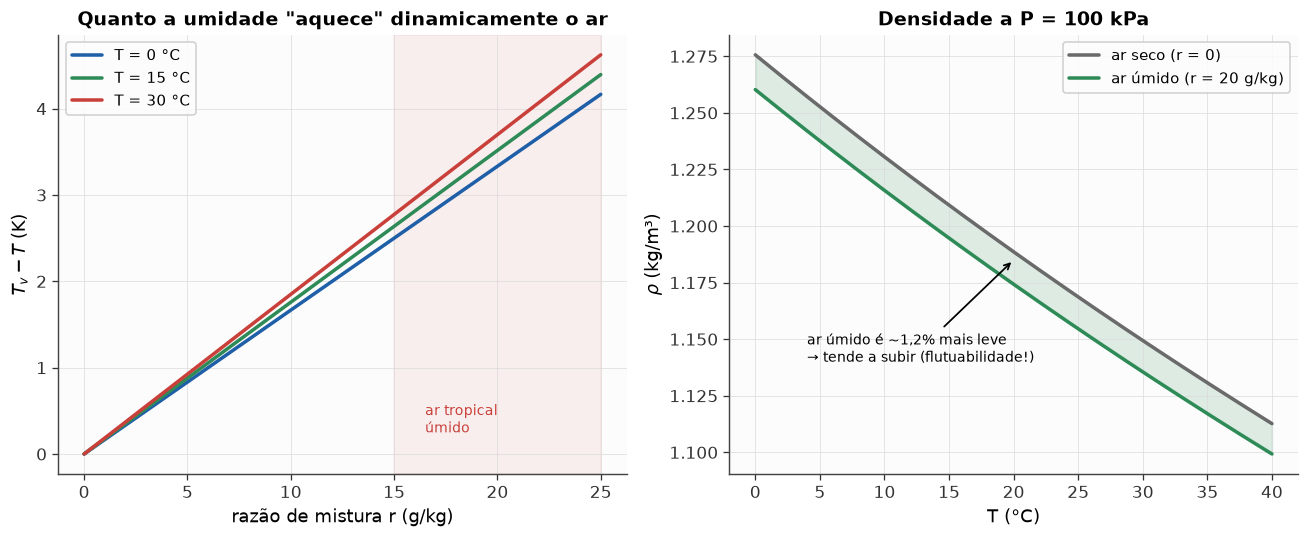

Exemplo das notas: T = 25 °C, r = 20 g/kg  →  Tv = 301.8 K = 28.6 °C


In [8]:
r_g = np.linspace(0, 25, 200)   # g/kg

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.8))
for T_C, cor in [(0, CORES['azul']), (15, CORES['verde']), (30, CORES['vermelho'])]:
    T_K = T_C + 273.15
    ax1.plot(r_g, T_K*0.61*r_g/1000, color=cor, label=f'T = {T_C} °C')
ax1.axvspan(15, 25, color=CORES['vermelho'], alpha=0.07)
ax1.text(16.5, 0.25, 'ar tropical\númido', fontsize=9, color=CORES['vermelho'])
ax1.set(xlabel='razão de mistura r (g/kg)', ylabel='$T_v - T$ (K)',
        title='Quanto a umidade "aquece" dinamicamente o ar')
ax1.legend()

# densidade: ar seco vs. ar úmido a P = 100 kPa
T_C = np.linspace(0, 40, 200); T_K = T_C + 273.15
rho_seco  = 100e3/(Rd*T_K)
rho_umido = 100e3/(Rd*T_K*(1 + 0.61*0.020))
ax2.plot(T_C, rho_seco, color=CORES['cinza'], label='ar seco (r = 0)')
ax2.plot(T_C, rho_umido, color=CORES['verde'], label='ar úmido (r = 20 g/kg)')
ax2.fill_between(T_C, rho_umido, rho_seco, color=CORES['verde'], alpha=0.15)
ax2.annotate('ar úmido é ~1,2% mais leve\n→ tende a subir (flutuabilidade!)',
             xy=(20, 1.185), xytext=(4, 1.14), fontsize=9,
             arrowprops=dict(arrowstyle='->', lw=1.1))
ax2.set(xlabel='T (°C)', ylabel='$\\rho$ (kg/m³)',
        title='Densidade a P = 100 kPa')
ax2.legend()
fig.tight_layout(); plt.show()

T = 298.15; rr = 0.020
print(f'Exemplo das notas: T = 25 °C, r = 20 g/kg  →  '
      f'Tv = {T*(1+0.61*rr):.1f} K = {T*(1+0.61*rr)-273.15:.1f} °C')

---
## Exercícios numéricos complementares

Resolva nas células abaixo. Os enunciados completos (e os exercícios teóricos T1–T5) estão nas notas de aula; **soluções em `cap01_solucoes.ipynb`**.

**N1 — Troposfera politrópica.** Integre numericamente $dP/dz = -gP/(\Re_d T)$ com $T(z) = T_0 - \gamma z$ ($T_0 = 288{,}15$ K, $\gamma = 6{,}5$ K/km) de 0 a 11 km e compare com a solução analítica $P = P_0\,(1-\gamma z/T_0)^{g/(\Re_d\gamma)}$ (deduzida no exercício teórico T2). Trace o erro relativo.

**N2 — Escala de altura por ajuste.** Usando `ambiance`, ajuste por mínimos quadrados a melhor escala $H_p$ em $\ln P = \ln P_0 - z/H_p$ no intervalo 0–20 km. Compare com os 7,29 km do livro e ache as altitudes em que $P$ vale $\tfrac12$, $\tfrac14$ e $\tfrac1{10}$ de $P_0$.

**N3 — Altímetro de elevador.** Com a série de pressão fornecida abaixo (elevador de um prédio, uma leitura por segundo), reconstrua $z(t)$ pela hipsométrica e determine a altura total e a velocidade média do elevador ($T = 24$ °C constante).

**N4 — Espessura da sondagem.** Para a sondagem do Caso 4, calcule com MetPy a espessura 1000–500 hPa e diga se, pela regra dos 5400 m, esta atmosfera daria chuva ou neve. Repita esfriando a sondagem inteira em 30 K.

In [9]:
# N1 — sua solução aqui


In [10]:
# N2 — sua solução aqui


In [11]:
# N3 — sua solução aqui. Dados do elevador (P em kPa, 1 leitura/segundo):
P_elev = np.array([101.320, 101.320, 101.315, 101.300, 101.278, 101.252,
                   101.224, 101.196, 101.168, 101.140, 101.118, 101.102,
                   101.094, 101.092, 101.092])


In [12]:
# N4 — sua solução aqui


---
*Material derivado de R. Stull, Practical Meteorology (CC BY-NC-SA 4.0); este notebook herda a mesma licença.*